In [17]:
# ============================================
# 最重要：必须在 import torch 之前设置
# ============================================
import os

# 使用单个GPU（显存最大的那个）
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # 使用GPU 0
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# 限制PyTorch内存使用
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

# 然后再导入 PyTorch 和其他库
import gc
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GATv2Conv
from torch_geometric.utils import from_scipy_sparse_matrix
from sklearn.neighbors import kneighbors_graph
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from itertools import product

warnings.filterwarnings("ignore")

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print(f"使用设备: {device}")

# 打印 GPU 信息
if torch.cuda.is_available():
    print(f"CUDA 版本: {torch.version.cuda}")
    print(f"当前使用 GPU: {torch.cuda.current_device()}")
    print(f"GPU 名称: {torch.cuda.get_device_name()}")
    print(
        f"总显存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )
    print(f"当前可用显存: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")

使用设备: cuda
CUDA 版本: 11.8
当前使用 GPU: 0
GPU 名称: NVIDIA GeForce RTX 3080
总显存: 19.72 GB
当前可用显存: 15.94 GB


In [18]:
# ============================================
# 1. 加载数据（保持原文件格式）
# ============================================
print("\n" + "=" * 60)
print("1. 加载数据")
print("=" * 60)

df = pd.read_csv("./data/xenium_for_gnn.csv")
print(f"数据形状: {df.shape}")

# 删除缺失值
df = df.dropna()
print(f"删除缺失值后数据形状: {df.shape}")


1. 加载数据
数据形状: (406611, 54)
删除缺失值后数据形状: (406611, 54)


In [19]:
# ============================================
# 2. 提取特征和标签
# ============================================
print("\n" + "=" * 60)
print("2. 提取特征和标签")
print("=" * 60)

# 提取空间坐标
coords = df[["x_centroid", "y_centroid"]].values
print(f"坐标矩阵形状: {coords.shape}")

# 提取PCA特征
pca_cols = [col for col in df.columns if col.startswith("PC_")]
features = df[pca_cols].values
print(f"PCA特征形状: {features.shape}")

# 标准化特征
scaler = StandardScaler()
features = scaler.fit_transform(features)

# 提取标签
labels_raw = df["predicted_cell_type"].values
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels_raw)
num_classes = len(label_encoder.classes_)
print(f"类别数: {num_classes}")

# 统计各类别样本数
class_counts = pd.Series(labels).value_counts().sort_index()
print(f"各类别样本数:")
for i, count in class_counts.items():
    print(f"  类别 {i}: {count}")


2. 提取特征和标签
坐标矩阵形状: (406611, 2)


PCA特征形状: (406611, 50)
类别数: 16
各类别样本数:
  类别 0: 3451
  类别 1: 22071
  类别 2: 6734
  类别 3: 2298
  类别 4: 2650
  类别 5: 51693
  类别 6: 32368
  类别 7: 2673
  类别 8: 18438
  类别 9: 37912
  类别 10: 47557
  类别 11: 25010
  类别 12: 11085
  类别 13: 50487
  类别 14: 55335
  类别 15: 36849


In [20]:
# ============================================
# 3. 构建空间邻接图（使用较小的k值避免内存问题）
# ============================================
print("\n" + "=" * 60)
print("3. 构建空间邻接图")
print("=" * 60)


def build_spatial_graph(coords, k=10):
    """构建空间邻接图"""
    adj_matrix = kneighbors_graph(
        coords, n_neighbors=k, mode="connectivity", include_self=False
    )
    edge_index, _ = from_scipy_sparse_matrix(adj_matrix)
    return edge_index


# 尝试不同的k值
k_values = [5, 10, 15]
for k in k_values:
    edge_index = build_spatial_graph(coords, k=k)
    print(
        f"k={k}: 边数量={edge_index.shape[1]}, 平均度={2 * edge_index.shape[1] / coords.shape[0]:.2f}"
    )

# 使用较小的k值减少内存占用
DEFAULT_K = 5
edge_index = build_spatial_graph(coords, k=DEFAULT_K)
print(f"\n使用 k={DEFAULT_K} 构建图")
print(f"边数量: {edge_index.shape[1]}")


3. 构建空间邻接图
k=5: 边数量=2033055, 平均度=10.00
k=10: 边数量=4066110, 平均度=20.00
k=15: 边数量=6099165, 平均度=30.00

使用 k=5 构建图
边数量: 2033055


In [21]:
# ============================================
# 4. 创建PyTorch Geometric数据对象
# ============================================
print("\n" + "=" * 60)
print("4. 创建PyTorch Geometric数据对象")
print("=" * 60)

# 转换为Tensor
x = torch.FloatTensor(features)
y = torch.LongTensor(labels)
edge_index = edge_index.to(torch.long)

# 创建数据对象
data = Data(x=x, edge_index=edge_index, y=y)

print(f"节点数: {data.num_nodes}")
print(f"特征维度: {data.num_features}")
print(f"边数: {data.num_edges}")
print(f"类别数: {num_classes}")


4. 创建PyTorch Geometric数据对象
节点数: 406611
特征维度: 50
边数: 2033055
类别数: 16


In [22]:
# ============================================
# 5. 划分数据集
# ============================================
print("\n" + "=" * 60)
print("5. 划分数据集")
print("=" * 60)

indices = np.arange(data.num_nodes)
train_val_idx, test_idx = train_test_split(
    indices, test_size=0.2, stratify=labels, random_state=42
)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.25, stratify=labels[train_val_idx], random_state=42
)

train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

print(f"训练集大小: {train_mask.sum().item()}")
print(f"验证集大小: {val_mask.sum().item()}")
print(f"测试集大小: {test_mask.sum().item()}")


5. 划分数据集
训练集大小: 243966
验证集大小: 81322
测试集大小: 81323


In [23]:
# ============================================
# 6. 定义所有图神经网络模型
# ============================================
print("\n" + "=" * 60)
print("6. 定义图神经网络模型")
print("=" * 60)


# 6.1 MLP模型（基线模型）
class MLPWithDropout(nn.Module):
    """多层感知机（基线模型）"""

    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.3, num_layers=2):
        super(MLPWithDropout, self).__init__()
        self.layers = nn.ModuleList()
        self.bns = nn.ModuleList()

        self.layers.append(nn.Linear(in_dim, hidden_dim))
        self.bns.append(nn.BatchNorm1d(hidden_dim))

        for i in range(num_layers - 2):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        self.layers.append(nn.Linear(hidden_dim, out_dim))
        self.dropout = dropout

    def forward(self, data):
        x = data.x
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.layers[-1](x)
        return F.log_softmax(x, dim=1)


# 6.2 改进的GCN模型
class ImprovedGCN(nn.Module):
    """改进的GCN模型：跳跃连接 + 批归一化"""

    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.3, num_layers=2):
        super(ImprovedGCN, self).__init__()
        self.num_layers = num_layers
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        self.convs.append(GCNConv(in_dim, hidden_dim))
        self.bns.append(nn.BatchNorm1d(hidden_dim))

        for i in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        self.convs.append(GCNConv(hidden_dim, out_dim))
        self.dropout = dropout
        self.skip_proj = nn.Linear(in_dim, hidden_dim) if num_layers >= 2 else None

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        identity = x

        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            if i == 0 and self.skip_proj is not None:
                x = x + self.skip_proj(identity)

        x = self.convs[-1](x, edge_index)
        return F.log_softmax(x, dim=1)


# 6.3 GraphSAGE模型
class GraphSAGEWithNorm(nn.Module):
    """带批归一化的GraphSAGE模型"""

    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.3, num_layers=2):
        super(GraphSAGEWithNorm, self).__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        self.convs.append(SAGEConv(in_dim, hidden_dim))
        self.bns.append(nn.BatchNorm1d(hidden_dim))

        for i in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        self.convs.append(SAGEConv(hidden_dim, out_dim))
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return F.log_softmax(x, dim=1)


# 6.4 完整的GAT模型
class GAT(nn.Module):
    """
    完整的GAT模型：
    1. 支持多层GAT
    2. 支持多头注意力
    3. 支持跳跃连接
    4. 支持批归一化
    """

    def __init__(
        self,
        in_dim,
        hidden_dim,
        out_dim,
        heads=8,
        dropout=0.3,
        num_layers=2,
        use_skip=True,
    ):
        super(GAT, self).__init__()
        self.num_layers = num_layers
        self.use_skip = use_skip

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # 第一层：输入到隐藏层（多头）
        self.convs.append(
            GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout, concat=True)
        )
        self.bns.append(nn.BatchNorm1d(hidden_dim * heads))

        # 中间层
        for i in range(num_layers - 2):
            self.convs.append(
                GATConv(
                    hidden_dim * heads,
                    hidden_dim,
                    heads=heads,
                    dropout=dropout,
                    concat=True,
                )
            )
            self.bns.append(nn.BatchNorm1d(hidden_dim * heads))

        # 最后一层：隐藏层到输出层（单头）
        self.convs.append(
            GATConv(hidden_dim * heads, out_dim, heads=1, dropout=dropout, concat=False)
        )

        self.dropout = dropout

        # 跳跃连接
        if use_skip and num_layers >= 2:
            self.skip_proj = nn.Linear(in_dim, hidden_dim * heads)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        if self.use_skip and self.num_layers >= 2:
            identity = self.skip_proj(x)

        # 前面的层
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

            # 跳跃连接（只在第一层后）
            if self.use_skip and i == 0 and self.num_layers >= 2:
                x = x + identity

        # 输出层
        x = self.convs[-1](x, edge_index)
        return F.log_softmax(x, dim=1)


# 6.5 GATv2模型（改进版）
class GATv2Model(nn.Module):
    """
    GATv2模型：动态注意力机制的改进版本
    """

    def __init__(self, in_dim, hidden_dim, out_dim, heads=8, dropout=0.3, num_layers=2):
        super(GATv2Model, self).__init__()
        self.num_layers = num_layers

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # 第一层
        self.convs.append(
            GATv2Conv(in_dim, hidden_dim, heads=heads, dropout=dropout, concat=True)
        )
        self.bns.append(nn.BatchNorm1d(hidden_dim * heads))

        # 中间层
        for i in range(num_layers - 2):
            self.convs.append(
                GATv2Conv(
                    hidden_dim * heads,
                    hidden_dim,
                    heads=heads,
                    dropout=dropout,
                    concat=True,
                )
            )
            self.bns.append(nn.BatchNorm1d(hidden_dim * heads))

        # 输出层
        self.convs.append(
            GATv2Conv(
                hidden_dim * heads, out_dim, heads=1, dropout=dropout, concat=False
            )
        )

        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.convs[-1](x, edge_index)
        return F.log_softmax(x, dim=1)


print("所有模型定义完成")


6. 定义图神经网络模型
所有模型定义完成


In [ ]:
# ============================================
# 7. 训练和评估函数
# ============================================
print("\n" + "=" * 60)
print("7. 定义训练和评估函数")
print("=" * 60)


# def train_model(model, data, optimizer, epochs=500, patience=50, verbose=True):
#     """训练模型 - 支持多GPU"""
#     # 将数据移到设备
#     data = data.to(device)

#     model = model.to(device)

#     best_val_acc = 0
#     best_val_loss = float("inf")
#     best_model_state = None
#     patience_counter = 0

#     train_losses, val_losses = [], []
#     train_accs, val_accs = [], []

#     for epoch in range(epochs):
#         # 训练阶段
#         model.train()
#         optimizer.zero_grad()

#         out = model(data)
#         loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
#         loss.backward()
#         optimizer.step()

#         # 计算训练准确率
#         pred = out.argmax(dim=1)
#         train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()

#         # 验证阶段
#         model.eval()
#         with torch.no_grad():
#             out = model(data)
#             val_loss = F.nll_loss(out[data.val_mask], data.y[data.val_mask])
#             val_acc = (pred[data.val_mask] == data.y[data.val_mask]).float().mean().item()

#         train_losses.append(loss.item())
#         val_losses.append(val_loss.item())
#         train_accs.append(train_acc)
#         val_accs.append(val_acc)

#         # 早停检查
#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             best_val_loss = val_loss
#             # 保存模型状态时，如果使用了DataParallel，需要保存module的状态
#             if isinstance(model, nn.DataParallel):
#                 best_model_state = model.module.state_dict().copy()
#             else:
#                 best_model_state = model.state_dict().copy()
#             patience_counter = 0
#         else:
#             patience_counter += 1

#         if patience_counter >= patience:
#             if verbose:
#                 print(f"  早停于 epoch {epoch+1}")
#             break

#         if verbose and (epoch + 1) % 50 == 0:
#             print(f"  Epoch {epoch+1:4d}/{epochs} | "
#                   f"Train Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f} | "
#                   f"Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc:.4f}")

#     # 加载最佳模型
#     if best_model_state is not None:
#         if isinstance(model, nn.DataParallel):
#             model.module.load_state_dict(best_model_state)
#         else:
#             model.load_state_dict(best_model_state)

#     if verbose:
#         print(f"\n最佳验证结果: Val Acc: {best_val_acc:.4f}, Val Loss: {best_val_loss:.4f}")


#     return model, train_losses, val_losses, train_accs, val_accs, best_val_acc
def train_model(
    model,
    data,
    optimizer,
    epochs=500,
    patience=50,
    verbose=True,
    gradient_accumulation_steps=1,
):
    """
    使用混合精度训练和梯度累积训练模型
    - 混合精度：减少40-50%显存
    - 梯度累积：模拟更大的batch size，减少梯度更新频率
    """
    # 将数据移到设备
    data = data.to(device)
    model = model.to(device)

    # 创建GradScaler用于混合精度训练
    scaler = torch.cuda.amp.GradScaler()

    best_val_acc = 0
    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # 训练阶段
        model.train()
        optimizer.zero_grad()
        total_loss = 0

        # 使用混合精度进行前向和反向传播
        with torch.cuda.amp.autocast():
            out = model(data)
            loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
            # 梯度累积：将loss除以累积步数
            loss = loss / gradient_accumulation_steps

        # 反向传播（使用scaler处理混合精度）
        scaler.scale(loss).backward()

        # 梯度累积：每gradient_accumulation_steps步更新一次参数
        if (epoch + 1) % gradient_accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss = loss.item() * gradient_accumulation_steps

        # 计算训练准确率（在原始精度下计算）
        with torch.cuda.amp.autocast():
            out = model(data)
        pred = out.argmax(dim=1)
        train_acc = (
            (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()
        )

        # 验证阶段（不需要梯度，使用混合精度加速）
        model.eval()
        with torch.no_grad(), torch.cuda.amp.autocast():
            out = model(data)
            val_loss = F.nll_loss(out[data.val_mask], data.y[data.val_mask])
            val_acc = (
                (pred[data.val_mask] == data.y[data.val_mask]).float().mean().item()
            )

        train_losses.append(total_loss)
        val_losses.append(val_loss.item())
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # 早停检查
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            # 保存模型状态时，如果使用了DataParallel，需要保存module的状态
            if isinstance(model, nn.DataParallel):
                best_model_state = model.module.state_dict().copy()
            else:
                best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            if verbose:
                print(f"  早停于 epoch {epoch+1}")
            break

        if verbose and (epoch + 1) % 50 == 0:
            print(
                f"  Epoch {epoch+1:4d}/{epochs} | "
                f"Train Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc:.4f}"
            )

        # 定期清理显存
        if (epoch + 1) % 100 == 0:
            clear_memory()

    # 加载最佳模型
    if best_model_state is not None:
        if isinstance(model, nn.DataParallel):
            model.module.load_state_dict(best_model_state)
        else:
            model.load_state_dict(best_model_state)

    if verbose:
        print(
            f"\n最佳验证结果: Val Acc: {best_val_acc:.4f}, Val Loss: {best_val_loss:.4f}"
        )

    return model, train_losses, val_losses, train_accs, val_accs, best_val_acc


def evaluate_model(model, data):
    """评估模型"""
    model.eval()
    data = data.to(device)

    with torch.no_grad():
        out = model(data)
        pred = out.argmax(dim=1)

        test_pred = pred[data.test_mask].cpu().numpy()
        test_true = data.y[data.test_mask].cpu().numpy()

        test_acc = accuracy_score(test_true, test_pred)
        test_f1_macro = f1_score(test_true, test_pred, average="macro")
        test_f1_weighted = f1_score(test_true, test_pred, average="weighted")

        return test_acc, test_f1_macro, test_f1_weighted, test_pred, test_true


def plot_training_curves(results_dict, model_name, save_path=None):
    """绘制训练曲线"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 损失曲线
    axes[0].plot(results_dict["train_losses"], label="Train Loss", alpha=0.7)
    axes[0].plot(results_dict["val_losses"], label="Val Loss", alpha=0.7)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{model_name} - Loss Curves")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 准确率曲线
    axes[1].plot(results_dict["train_accs"], label="Train Acc", alpha=0.7)
    axes[1].plot(results_dict["val_accs"], label="Val Acc", alpha=0.7)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{model_name} - Accuracy Curves")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def clear_memory():
    """清理GPU显存"""
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        # 重置峰值内存统计
        torch.cuda.reset_peak_memory_stats()
    gc.collect()


7. 定义训练和评估函数


In [25]:
# ============================================
# 8. 模型参数实验配置
# ============================================
print("\n" + "=" * 60)
print("8. 模型参数实验配置")
print("=" * 60)

in_dim = data.num_features
out_dim = num_classes

# 定义不同模型的参数网格
param_grids = {
    "MLP": {"hidden_dim": [128, 256], "dropout": [0.3, 0.5], "num_layers": [2, 3]},
    "GCN_Improved": {
        "hidden_dim": [128, 256],
        "dropout": [0.3, 0.5],
        "num_layers": [2, 3],
    },
    "GraphSAGE": {
        "hidden_dim": [128, 256],
        "dropout": [0.3, 0.5],
        "num_layers": [2, 3],
    },
    "GAT": {
        "hidden_dim": [64, 128],
        "heads": [4, 8],
        "dropout": [0.3, 0.5],
        "num_layers": [2, 3],
        "use_skip": [True, False],
    },
    "GATv2": {
        "hidden_dim": [64, 128],
        "heads": [4, 8],
        "dropout": [0.3, 0.5],
        "num_layers": [2, 3],
    },
}


8. 模型参数实验配置


In [26]:
# ============================================
# 9. 执行参数实验
# ============================================
print("\n" + "=" * 60)
print("9. 执行模型参数实验")
print("=" * 60)

all_results = {}
best_models = {}

# 9.1 MLP参数实验
print("\n" + "=" * 50)
print("9.1 MLP 参数实验")
print("=" * 50)

mlp_results = []
param_combinations = list(
    product(
        param_grids["MLP"]["hidden_dim"],
        param_grids["MLP"]["dropout"],
        param_grids["MLP"]["num_layers"],
    )
)

for hidden_dim, dropout, num_layers in param_combinations:
    print(
        f"\n训练 MLP (hidden_dim={hidden_dim}, dropout={dropout}, num_layers={num_layers})"
    )

    model = MLPWithDropout(in_dim, hidden_dim, out_dim, dropout, num_layers)
    print(f"  参数量: {sum(p.numel() for p in model.parameters()):,}")

    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

    trained_model, train_losses, val_losses, train_accs, val_accs, best_val_acc = (
        train_model(model, data, optimizer, epochs=500, patience=50, verbose=False)
    )

    test_acc, test_f1_macro, test_f1_weighted, _, _ = evaluate_model(
        trained_model, data
    )

    result = {
        "model": "MLP",
        "hidden_dim": hidden_dim,
        "dropout": dropout,
        "num_layers": num_layers,
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "test_f1_macro": test_f1_macro,
        "test_f1_weighted": test_f1_weighted,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "model_obj": trained_model,
    }
    mlp_results.append(result)
    if 'trained_model' in locals():
        del trained_model
    clear_memory()
    print(
        f"  验证准确率: {best_val_acc:.4f} | 测试准确率: {test_acc:.4f} | F1: {test_f1_macro:.4f}"
    )

# 找到MLP最佳模型
best_mlp = max(mlp_results, key=lambda x: x["best_val_acc"])
all_results["MLP"] = mlp_results
best_models["MLP"] = best_mlp
print(
    f"\nMLP 最佳模型: hidden_dim={best_mlp['hidden_dim']}, dropout={best_mlp['dropout']}, "
    f"num_layers={best_mlp['num_layers']}, Test Acc={best_mlp['test_acc']:.4f}"
)


9. 执行模型参数实验

9.1 MLP 参数实验

训练 MLP (hidden_dim=128, dropout=0.3, num_layers=2)
  参数量: 8,848
  验证准确率: 0.8736 | 测试准确率: 0.8834 | F1: 0.8714

训练 MLP (hidden_dim=128, dropout=0.3, num_layers=3)
  参数量: 25,616
  验证准确率: 0.8735 | 测试准确率: 0.8883 | F1: 0.8763

训练 MLP (hidden_dim=128, dropout=0.5, num_layers=2)
  参数量: 8,848
  验证准确率: 0.8636 | 测试准确率: 0.8780 | F1: 0.8648

训练 MLP (hidden_dim=128, dropout=0.5, num_layers=3)
  参数量: 25,616
  验证准确率: 0.8594 | 测试准确率: 0.8815 | F1: 0.8678

训练 MLP (hidden_dim=256, dropout=0.3, num_layers=2)
  参数量: 17,680
  验证准确率: 0.8798 | 测试准确率: 0.8870 | F1: 0.8748

训练 MLP (hidden_dim=256, dropout=0.3, num_layers=3)
  参数量: 83,984
  验证准确率: 0.8802 | 测试准确率: 0.8915 | F1: 0.8799

训练 MLP (hidden_dim=256, dropout=0.5, num_layers=2)
  参数量: 17,680
  验证准确率: 0.8744 | 测试准确率: 0.8853 | F1: 0.8733

训练 MLP (hidden_dim=256, dropout=0.5, num_layers=3)
  参数量: 83,984
  验证准确率: 0.8723 | 测试准确率: 0.8876 | F1: 0.8748

MLP 最佳模型: hidden_dim=256, dropout=0.3, num_layers=3, Test Acc=0.8915


In [27]:
# 9.2 GCN参数实验
print("\n" + "=" * 50)
print("9.2 GCN_Improved 参数实验")
print("=" * 50)

gcn_results = []
param_combinations = list(
    product(
        param_grids["GCN_Improved"]["hidden_dim"],
        param_grids["GCN_Improved"]["dropout"],
        param_grids["GCN_Improved"]["num_layers"],
    )
)

for hidden_dim, dropout, num_layers in param_combinations:
    print(
        f"\n训练 GCN (hidden_dim={hidden_dim}, dropout={dropout}, num_layers={num_layers})"
    )

    model = ImprovedGCN(in_dim, hidden_dim, out_dim, dropout, num_layers)
    print(f"  参数量: {sum(p.numel() for p in model.parameters()):,}")

    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

    trained_model, train_losses, val_losses, train_accs, val_accs, best_val_acc = (
        train_model(model, data, optimizer, epochs=500, patience=50, verbose=False)
    )

    test_acc, test_f1_macro, test_f1_weighted, _, _ = evaluate_model(
        trained_model, data
    )

    result = {
        "model": "GCN",
        "hidden_dim": hidden_dim,
        "dropout": dropout,
        "num_layers": num_layers,
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "test_f1_macro": test_f1_macro,
        "test_f1_weighted": test_f1_weighted,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "model_obj": trained_model,
    }
    gcn_results.append(result)
    if 'trained_model' in locals():
        del trained_model
    clear_memory()
    print(
        f"  验证准确率: {best_val_acc:.4f} | 测试准确率: {test_acc:.4f} | F1: {test_f1_macro:.4f}"
    )

best_gcn = max(gcn_results, key=lambda x: x["best_val_acc"])
all_results["GCN"] = gcn_results
best_models["GCN"] = best_gcn
print(
    f"\nGCN 最佳模型: hidden_dim={best_gcn['hidden_dim']}, dropout={best_gcn['dropout']}, "
    f"num_layers={best_gcn['num_layers']}, Test Acc={best_gcn['test_acc']:.4f}"
)


9.2 GCN_Improved 参数实验

训练 GCN (hidden_dim=128, dropout=0.3, num_layers=2)
  参数量: 15,376
  验证准确率: 0.6163 | 测试准确率: 0.6199 | F1: 0.5982

训练 GCN (hidden_dim=128, dropout=0.3, num_layers=3)
  参数量: 32,144
  验证准确率: 0.6474 | 测试准确率: 0.6601 | F1: 0.6379

训练 GCN (hidden_dim=128, dropout=0.5, num_layers=2)
  参数量: 15,376
  验证准确率: 0.6144 | 测试准确率: 0.6190 | F1: 0.5952

训练 GCN (hidden_dim=128, dropout=0.5, num_layers=3)
  参数量: 32,144
  验证准确率: 0.6363 | 测试准确率: 0.6501 | F1: 0.6221

训练 GCN (hidden_dim=256, dropout=0.3, num_layers=2)
  参数量: 30,736
  验证准确率: 0.6158 | 测试准确率: 0.6201 | F1: 0.5997

训练 GCN (hidden_dim=256, dropout=0.3, num_layers=3)
  参数量: 97,040
  验证准确率: 0.6501 | 测试准确率: 0.6601 | F1: 0.6383

训练 GCN (hidden_dim=256, dropout=0.5, num_layers=2)
  参数量: 30,736
  验证准确率: 0.6167 | 测试准确率: 0.6206 | F1: 0.5997

训练 GCN (hidden_dim=256, dropout=0.5, num_layers=3)
  参数量: 97,040
  验证准确率: 0.6468 | 测试准确率: 0.6593 | F1: 0.6393

GCN 最佳模型: hidden_dim=256, dropout=0.3, num_layers=3, Test Acc=0.6601


In [28]:
# 9.3 GraphSAGE参数实验
print("\n" + "=" * 50)
print("9.3 GraphSAGE 参数实验")
print("=" * 50)

sage_results = []
param_combinations = list(
    product(
        param_grids["GraphSAGE"]["hidden_dim"],
        param_grids["GraphSAGE"]["dropout"],
        param_grids["GraphSAGE"]["num_layers"],
    )
)

for hidden_dim, dropout, num_layers in param_combinations:
    print(
        f"\n训练 GraphSAGE (hidden_dim={hidden_dim}, dropout={dropout}, num_layers={num_layers})"
    )

    model = GraphSAGEWithNorm(in_dim, hidden_dim, out_dim, dropout, num_layers)
    print(f"  参数量: {sum(p.numel() for p in model.parameters()):,}")

    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

    trained_model, train_losses, val_losses, train_accs, val_accs, best_val_acc = (
        train_model(model, data, optimizer, epochs=500, patience=50, verbose=False)
    )

    test_acc, test_f1_macro, test_f1_weighted, _, _ = evaluate_model(
        trained_model, data
    )

    result = {
        "model": "GraphSAGE",
        "hidden_dim": hidden_dim,
        "dropout": dropout,
        "num_layers": num_layers,
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "test_f1_macro": test_f1_macro,
        "test_f1_weighted": test_f1_weighted,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "model_obj": trained_model,
    }
    sage_results.append(result)
    if "trained_model" in locals():
        del trained_model
    clear_memory()
    print(
        f"  验证准确率: {best_val_acc:.4f} | 测试准确率: {test_acc:.4f} | F1: {test_f1_macro:.4f}"
    )

best_sage = max(sage_results, key=lambda x: x["best_val_acc"])
all_results["GraphSAGE"] = sage_results
best_models["GraphSAGE"] = best_sage
print(
    f"\nGraphSAGE 最佳模型: hidden_dim={best_sage['hidden_dim']}, dropout={best_sage['dropout']}, "
    f"num_layers={best_sage['num_layers']}, Test Acc={best_sage['test_acc']:.4f}"
)


9.3 GraphSAGE 参数实验

训练 GraphSAGE (hidden_dim=128, dropout=0.3, num_layers=2)
  参数量: 17,296
  验证准确率: 0.8725 | 测试准确率: 0.8821 | F1: 0.8694

训练 GraphSAGE (hidden_dim=128, dropout=0.3, num_layers=3)
  参数量: 50,448
  验证准确率: 0.8697 | 测试准确率: 0.8841 | F1: 0.8708

训练 GraphSAGE (hidden_dim=128, dropout=0.5, num_layers=2)
  参数量: 17,296
  验证准确率: 0.8629 | 测试准确率: 0.8786 | F1: 0.8639

训练 GraphSAGE (hidden_dim=128, dropout=0.5, num_layers=3)
  参数量: 50,448
  验证准确率: 0.8598 | 测试准确率: 0.8809 | F1: 0.8653

训练 GraphSAGE (hidden_dim=256, dropout=0.3, num_layers=2)
  参数量: 34,576
  验证准确率: 0.8768 | 测试准确率: 0.8839 | F1: 0.8717

训练 GraphSAGE (hidden_dim=256, dropout=0.3, num_layers=3)
  参数量: 166,416
  验证准确率: 0.8737 | 测试准确率: 0.8865 | F1: 0.8741

训练 GraphSAGE (hidden_dim=256, dropout=0.5, num_layers=2)
  参数量: 34,576
  验证准确率: 0.8730 | 测试准确率: 0.8841 | F1: 0.8716

训练 GraphSAGE (hidden_dim=256, dropout=0.5, num_layers=3)
  参数量: 166,416
  验证准确率: 0.8682 | 测试准确率: 0.8851 | F1: 0.8712

GraphSAGE 最佳模型: hidden_dim=256, dropout=0

In [29]:
# 9.4 GAT参数实验
print("\n" + "=" * 50)
print("9.4 GAT 参数实验")
print("=" * 50)

gat_results = []
param_combinations = list(
    product(
        param_grids["GAT"]["hidden_dim"],
        param_grids["GAT"]["heads"],
        param_grids["GAT"]["dropout"],
        param_grids["GAT"]["num_layers"],
        param_grids["GAT"]["use_skip"],
    )
)

for hidden_dim, heads, dropout, num_layers, use_skip in param_combinations:
    print(
        f"\n训练 GAT (hidden_dim={hidden_dim}, heads={heads}, dropout={dropout}, "
        f"num_layers={num_layers}, use_skip={use_skip})"
    )

    model = GAT(in_dim, hidden_dim, out_dim, heads, dropout, num_layers, use_skip)
    print(f"  参数量: {sum(p.numel() for p in model.parameters()):,}")

    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

    try:
        trained_model, train_losses, val_losses, train_accs, val_accs, best_val_acc = (
            train_model(model, data, optimizer, epochs=500, patience=50, verbose=False)
        )

        test_acc, test_f1_macro, test_f1_weighted, _, _ = evaluate_model(
            trained_model, data
        )

        result = {
            "model": "GAT",
            "hidden_dim": hidden_dim,
            "heads": heads,
            "dropout": dropout,
            "num_layers": num_layers,
            "use_skip": use_skip,
            "best_val_acc": best_val_acc,
            "test_acc": test_acc,
            "test_f1_macro": test_f1_macro,
            "test_f1_weighted": test_f1_weighted,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs,
            "model_obj": trained_model,
        }
        gat_results.append(result)
        if "trained_model" in locals():
            del trained_model
        clear_memory()
        print(
            f"  验证准确率: {best_val_acc:.4f} | 测试准确率: {test_acc:.4f} | F1: {test_f1_macro:.4f}"
        )

    except RuntimeError as e:
        print(f"  训练失败 (内存不足): {e}")
        continue

if gat_results:
    best_gat = max(gat_results, key=lambda x: x["best_val_acc"])
    all_results["GAT"] = gat_results
    best_models["GAT"] = best_gat
    print(
        f"\nGAT 最佳模型: hidden_dim={best_gat['hidden_dim']}, heads={best_gat['heads']}, "
        f"dropout={best_gat['dropout']}, num_layers={best_gat['num_layers']}, "
        f"use_skip={best_gat['use_skip']}, Test Acc={best_gat['test_acc']:.4f}"
    )


9.4 GAT 参数实验

训练 GAT (hidden_dim=64, heads=4, dropout=0.3, num_layers=2, use_skip=True)
  参数量: 31,280
  验证准确率: 0.6455 | 测试准确率: 0.6846 | F1: 0.6608

训练 GAT (hidden_dim=64, heads=4, dropout=0.3, num_layers=2, use_skip=False)
  参数量: 18,224
  验证准确率: 0.5955 | 测试准确率: 0.6226 | F1: 0.6033

训练 GAT (hidden_dim=64, heads=4, dropout=0.3, num_layers=3, use_skip=True)
  参数量: 98,096
  验证准确率: 0.6068 | 测试准确率: 0.6456 | F1: 0.6229

训练 GAT (hidden_dim=64, heads=4, dropout=0.3, num_layers=3, use_skip=False)
  参数量: 85,040
  验证准确率: 0.5730 | 测试准确率: 0.5914 | F1: 0.5662

训练 GAT (hidden_dim=64, heads=4, dropout=0.5, num_layers=2, use_skip=True)
  参数量: 31,280
  验证准确率: 0.6018 | 测试准确率: 0.6662 | F1: 0.6383

训练 GAT (hidden_dim=64, heads=4, dropout=0.5, num_layers=2, use_skip=False)
  参数量: 18,224
  验证准确率: 0.5634 | 测试准确率: 0.6140 | F1: 0.5924

训练 GAT (hidden_dim=64, heads=4, dropout=0.5, num_layers=3, use_skip=True)
  参数量: 98,096
  验证准确率: 0.5632 | 测试准确率: 0.6149 | F1: 0.5911

训练 GAT (hidden_dim=64, heads=4, dropout=0.5,

In [30]:
# 9.5 GATv2参数实验
print("\n" + "=" * 50)
print("9.5 GATv2 参数实验")
print("=" * 50)

gatv2_results = []
param_combinations = list(
    product(
        param_grids["GATv2"]["hidden_dim"],
        param_grids["GATv2"]["heads"],
        param_grids["GATv2"]["dropout"],
        param_grids["GATv2"]["num_layers"],
    )
)

for hidden_dim, heads, dropout, num_layers in param_combinations:
    print(
        f"\n训练 GATv2 (hidden_dim={hidden_dim}, heads={heads}, dropout={dropout}, num_layers={num_layers})"
    )

    model = GATv2Model(in_dim, hidden_dim, out_dim, heads, dropout, num_layers)
    print(f"  参数量: {sum(p.numel() for p in model.parameters()):,}")

    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

    try:
        trained_model, train_losses, val_losses, train_accs, val_accs, best_val_acc = (
            train_model(model, data, optimizer, epochs=500, patience=50, verbose=False)
        )

        test_acc, test_f1_macro, test_f1_weighted, _, _ = evaluate_model(
            trained_model, data
        )

        result = {
            "model": "GATv2",
            "hidden_dim": hidden_dim,
            "heads": heads,
            "dropout": dropout,
            "num_layers": num_layers,
            "best_val_acc": best_val_acc,
            "test_acc": test_acc,
            "test_f1_macro": test_f1_macro,
            "test_f1_weighted": test_f1_weighted,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs,
            "model_obj": trained_model,
        }
        gatv2_results.append(result)
        if "trained_model" in locals():
            del trained_model
        clear_memory()
        print(
            f"  验证准确率: {best_val_acc:.4f} | 测试准确率: {test_acc:.4f} | F1: {test_f1_macro:.4f}"
        )

    except RuntimeError as e:
        print(f"  训练失败 (内存不足): {e}")
        continue

if gatv2_results:
    best_gatv2 = max(gatv2_results, key=lambda x: x["best_val_acc"])
    all_results["GATv2"] = gatv2_results
    best_models["GATv2"] = best_gatv2
    print(
        f"\nGATv2 最佳模型: hidden_dim={best_gatv2['hidden_dim']}, heads={best_gatv2['heads']}, "
        f"dropout={best_gatv2['dropout']}, num_layers={best_gatv2['num_layers']}, "
        f"Test Acc={best_gatv2['test_acc']:.4f}"
    )


9.5 GATv2 参数实验

训练 GATv2 (hidden_dim=64, heads=4, dropout=0.3, num_layers=2)
  参数量: 35,392


  验证准确率: 0.7800 | 测试准确率: 0.8466 | F1: 0.8293

训练 GATv2 (hidden_dim=64, heads=4, dropout=0.3, num_layers=3)
  参数量: 168,000
  训练失败 (内存不足): CUDA out of memory. Tried to allocate 2.33 GiB. GPU 0 has a total capacity of 19.72 GiB of which 767.50 MiB is free. Including non-PyTorch memory, this process has 18.95 GiB memory in use. Of the allocated memory 18.67 GiB is allocated by PyTorch, and 17.54 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

训练 GATv2 (hidden_dim=64, heads=4, dropout=0.5, num_layers=2)
  参数量: 35,392
  验证准确率: 0.6877 | 测试准确率: 0.8121 | F1: 0.7928

训练 GATv2 (hidden_dim=64, heads=4, dropout=0.5, num_layers=3)
  参数量: 168,000
  训练失败 (内存不足): CUDA out of memory. Tried to allocate 2.33 GiB. GPU 0 has a total capacity of 19.72 GiB of which 767.50 M

In [31]:
# ============================================
# 10. 结果汇总
# ============================================
print("\n" + "=" * 60)
print("10. 结果汇总")
print("=" * 60)

# 创建结果汇总表
summary_data = []
for model_name, best_model in best_models.items():
    summary_data.append(
        {
            "Model": model_name,
            "Best Val Acc": best_model["best_val_acc"],
            "Test Acc": best_model["test_acc"],
            "Test F1 (Macro)": best_model["test_f1_macro"],
            "Test F1 (Weighted)": best_model["test_f1_weighted"],
            "Parameters": best_model.get("hidden_dim", "N/A"),
            "Dropout": best_model.get("dropout", "N/A"),
            "Layers": best_model.get("num_layers", "N/A"),
            "Heads": best_model.get("heads", "N/A"),
        }
    )

summary_df = pd.DataFrame(summary_data)
print("\n模型性能对比表:")
print(summary_df.to_string(index=False))

# 找出最佳模型
best_model_name = max(best_models.keys(), key=lambda x: best_models[x]["test_acc"])
print(f"\n🏆 最佳模型: {best_model_name}")
print(f"   测试准确率: {best_models[best_model_name]['test_acc']:.4f}")
print(f"   Macro F1: {best_models[best_model_name]['test_f1_macro']:.4f}")


10. 结果汇总

模型性能对比表:
    Model  Best Val Acc  Test Acc  Test F1 (Macro)  Test F1 (Weighted)  Parameters  Dropout  Layers Heads
      MLP      0.880155  0.891482         0.879941            0.890550         256      0.3       3   N/A
      GCN      0.650095  0.660133         0.638344            0.648260         256      0.3       3   N/A
GraphSAGE      0.876774  0.883895         0.871717            0.882798         256      0.3       2   N/A
      GAT      0.645520  0.684628         0.660752            0.677927          64      0.3       2     4
    GATv2      0.780023  0.846562         0.829333            0.844124          64      0.3       2     4

🏆 最佳模型: MLP
   测试准确率: 0.8915
   Macro F1: 0.8799



11. 绘制结果对比图


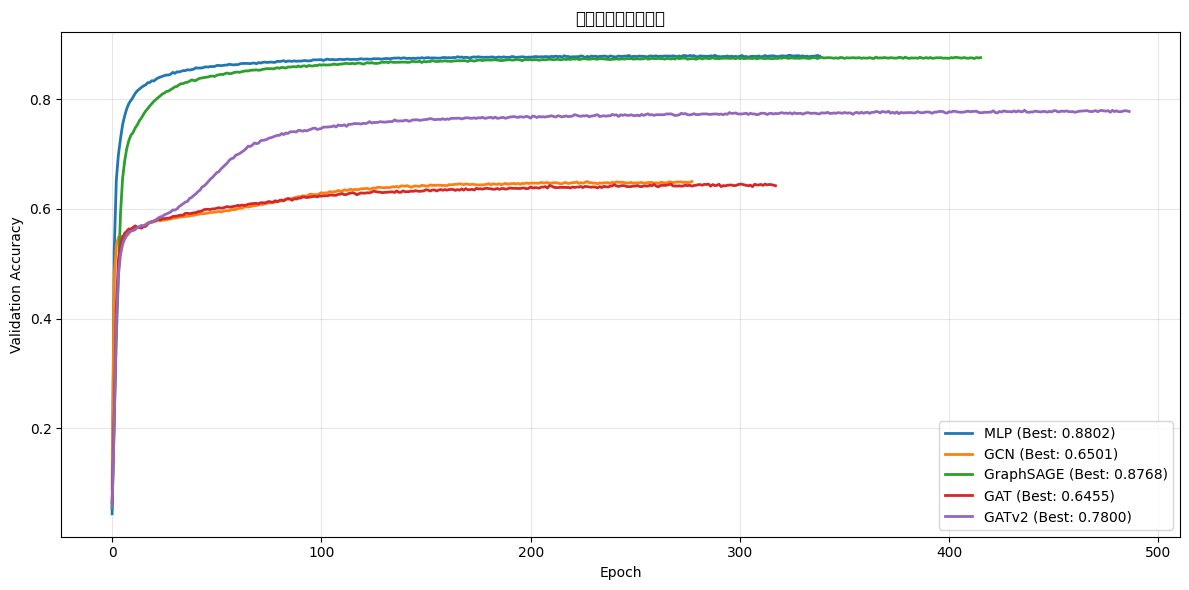

✅ 验证准确率对比图已保存: ./results/model_validation_comparison.png


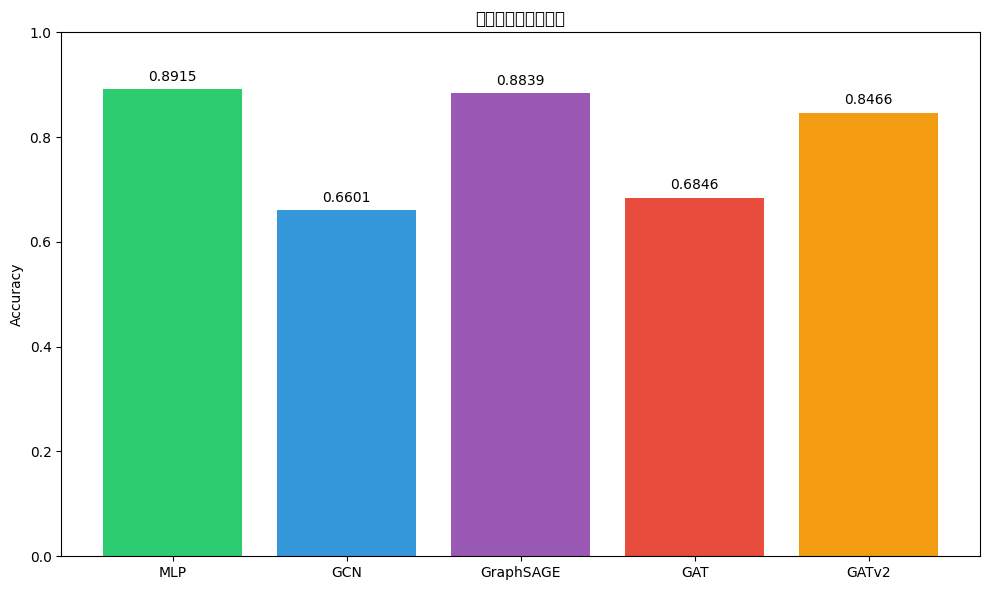

✅ 测试准确率对比图已保存: ./results/model_test_accuracy_comparison.png


In [32]:
# ============================================
# 11. 绘制对比图
# ============================================
print("\n" + "=" * 60)
print("11. 绘制结果对比图")
print("=" * 60)

# 绘制各模型验证准确率曲线对比
plt.figure(figsize=(12, 6))
for model_name, best_model in best_models.items():
    plt.plot(
        best_model["val_accs"],
        label=f"{model_name} (Best: {best_model['best_val_acc']:.4f})",
        linewidth=2,
    )
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("模型验证准确率对比")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./results/model_validation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 验证准确率对比图已保存: ./results/model_validation_comparison.png")

# 绘制测试准确率柱状图
plt.figure(figsize=(10, 6))
model_names = list(best_models.keys())
test_accs = [best_models[m]["test_acc"] for m in model_names]
colors = ["#2ecc71", "#3498db", "#9b59b6", "#e74c3c", "#f39c12"]
bars = plt.bar(model_names, test_accs, color=colors[: len(model_names)])
plt.ylabel("Accuracy")
plt.title("模型测试准确率对比")
plt.ylim(0, 1)
for bar, acc in zip(bars, test_accs):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
plt.tight_layout()
plt.savefig(
    "./results/model_test_accuracy_comparison.png", dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ 测试准确率对比图已保存: ./results/model_test_accuracy_comparison.png")

In [33]:
# ============================================
# 12. 保存结果
# ============================================
print("\n" + "=" * 60)
print("12. 保存结果")
print("=" * 60)

# 保存最佳模型的预测结果
best_model_obj = best_models[best_model_name]["model_obj"]
best_model_obj.eval()
data = data.to(device)

with torch.no_grad():
    out = best_model_obj(data)
    all_pred = out.argmax(dim=1).cpu().numpy()

true_labels = data.y.cpu().numpy()

# 保存预测结果
predictions_df = pd.DataFrame(
    {
        "cell_id": df["cell_id"],
        "x_centroid": coords[:, 0],
        "y_centroid": coords[:, 1],
        "true_label": label_encoder.inverse_transform(true_labels),
        "predicted_label": label_encoder.inverse_transform(all_pred),
        "is_correct": (all_pred == true_labels),
    }
)
predictions_df.to_csv("./results/final_predictions.csv", index=False)
print("✅ 预测结果已保存: ./results/final_predictions.csv")

# 保存结果汇总
summary_df.to_csv("./results/model_summary.csv", index=False)
print("✅ 结果汇总已保存: ./results/model_summary.csv")

print("\n" + "=" * 60)
print("实验完成！")
print("=" * 60)


12. 保存结果
✅ 预测结果已保存: ./results/final_predictions.csv
✅ 结果汇总已保存: ./results/model_summary.csv

实验完成！
